  dataset  head_idx  basis_idx  \
0    bmmc         0          0   
1    bmmc         1          0   
2    bmmc         3          0   
3    bmmc         3          0   
4    bmmc         1          1   

                                             GO_term  Adjusted_P_value  \
0  immune response-regulating cell surface recept...          0.047169   
1  mature conventional dendritic cell differentia...          0.010888   
2   regulation of cellular localization (GO:0060341)          0.015905   
3  regulation of membrane depolarization (GO:0003...          0.048686   
4  positive regulation of prostaglandin biosynthe...          0.004076   

   Combined_Score  
0     1014.390174  
1     5105.230681  
2      473.307073  
3      714.687962  
4     5105.230681  


C:\Users\Admin\AppData\Local\Temp\ipykernel_24944\3172177025.py:73: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.scatterplot(


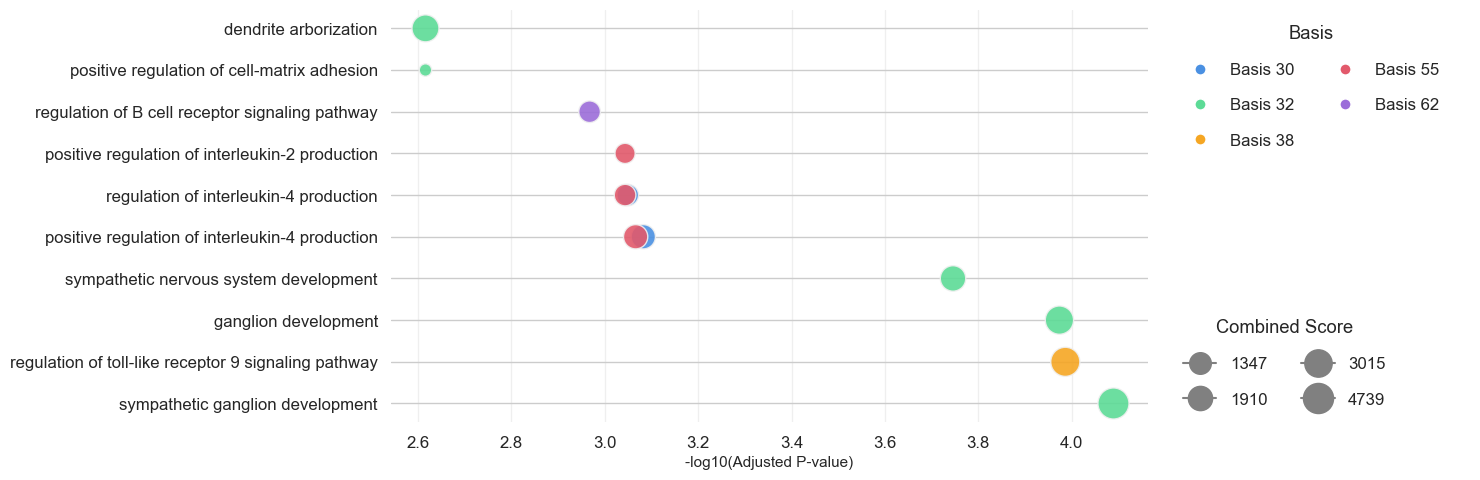

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from textwrap import wrap
from matplotlib.lines import Line2D

# ---------------------- CUSTOM PARAMETERS ----------------------
CSV_PATH = "data/bmmc_ALL_basis_significant_GO_summary.csv"
SAVE_PATH = "images/linformer_go_bmmc.png"
TOP_GO_TERMS = 10
#FONT_SANS_SERIF = 'Arial'
PLOT_FIGSIZE = (15, 5)
PALETTE_COLORS = ["#4A90E2", "#5CDB96", "#F5A623", "#E2596B", "#9B6DD9", "#5CC8DB"]
POINT_SIZE_RANGE = (80, 500)
DPI_VALUE = 300
GRID_ALPHA = 0.3
LABEL_SPACING = 1.2
FONT_SCALE = 1.1

#plt.rcParams['font.sans-serif'] = [FONT_SANS_SERIF]
plt.rcParams['axes.unicode_minus'] = False
sns.set(style="whitegrid", font_scale=FONT_SCALE)

df = pd.read_csv(CSV_PATH)
print(df.head())

# Calculate negative log10 P-value
df['neglog10P'] = -np.log10(df['Adjusted_P_value'])
df['GO_short'] = df['GO_term'].str.replace(r" \(GO:\d+\)", "", regex=True).str.strip()

# Group by basis index and GO term
df_basis = df.groupby(['basis_idx', 'GO_short'], as_index=False).agg({
    'neglog10P': 'max',
    'Combined_Score': 'max'
})

# Select top GO terms by maximum significance
top_go_names = (
    df_basis.groupby('GO_short')['neglog10P']
    .max()
    .nlargest(TOP_GO_TERMS)
    .index
)

df_plot = df_basis[df_basis['GO_short'].isin(top_go_names)].copy()

# Log scale for point size
df_plot['size_scaled'] = np.log1p(df_plot['Combined_Score'])

# Sort GO terms by significance
go_order = (
    df_plot.groupby('GO_short')['neglog10P']
    .max()
    .sort_values(ascending=True)
    .index
)

df_plot['GO_short'] = pd.Categorical(
    df_plot['GO_short'],
    categories=go_order,
    ordered=True
)

fig = plt.figure(figsize=PLOT_FIGSIZE)
gs = GridSpec(1, 2, width_ratios=[5, 2])

ax = fig.add_subplot(gs[0])
ax_leg = fig.add_subplot(gs[1])
ax_leg.axis('off')

sns.scatterplot(
    data=df_plot,
    x="neglog10P",
    y="GO_short",
    hue="basis_idx",
    size="size_scaled",
    sizes=POINT_SIZE_RANGE,
    palette=PALETTE_COLORS,
    edgecolor="#f0f0f0",
    linewidth=1,
    alpha=0.9,
    legend=False,
    ax=ax
)

unique_basis = sorted(df_plot['basis_idx'].unique())
hue_handles = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Basis {b}',
           markerfacecolor=PALETTE_COLORS[i % len(PALETTE_COLORS)],
           markersize=8)
    for i, b in enumerate(unique_basis)
]

# Calculate size quantiles
quantiles = df_plot['Combined_Score'].quantile([0.25, 0.5, 0.75, 0.95]).values
size_values = np.unique(np.round(quantiles, 0))

# Size mapping function
def map_size(v, vmin, vmax, smin=POINT_SIZE_RANGE[0], smax=POINT_SIZE_RANGE[1]):
    v_log = np.log1p(v)
    vmin_log = np.log1p(vmin)
    vmax_log = np.log1p(vmax)
    return smin + (v_log - vmin_log) / (vmax_log - vmin_log) * (smax - smin)

vmin = df_plot['Combined_Score'].min()
vmax = df_plot['Combined_Score'].max()

size_handles = [
    Line2D([0], [0], marker='o', color='gray',
           label=f"{int(v)}",
           markerfacecolor='gray',
           markersize=np.sqrt(map_size(v, vmin, vmax)))
    for v in size_values
]

# Add legends to dedicated axis
leg1 = ax_leg.legend(
    hue_handles, [h.get_label() for h in hue_handles],
    title="Basis", loc="upper left", frameon=False, labelspacing=LABEL_SPACING, ncol=2
)

leg2 = ax_leg.legend(
    size_handles, [h.get_label() for h in size_handles],
    title="Combined Score", loc="lower left", frameon=False, labelspacing=LABEL_SPACING, ncol=2
)

ax_leg.add_artist(leg1)

ax.set_xlabel("-log10(Adjusted P-value)", fontsize=11)
ax.set_ylabel("")
ax.grid(axis='x', alpha=GRID_ALPHA)
sns.despine(left=True, bottom=True, ax=ax)

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=DPI_VALUE, bbox_inches='tight', facecolor="white")
plt.show()

  dataset  head_idx  basis_idx  \
0  immune         2          0   
1  immune         2          0   
2  immune         2          0   
3  immune         2          0   
4  immune         2          0   

                                             GO_term  Adjusted_P_value  \
0          regulation of cell migration (GO:0030334)          0.009363   
1  regulation of endothelial cell apoptotic proce...          0.009363   
2  regulation of clathrin-dependent endocytosis (...          0.023401   
3  positive regulation of endothelial cell apopto...          0.023401   
4  regulation of blood vessel endothelial cell pr...          0.023401   

   Combined_Score  
0      127.908957  
1      548.716210  
2      920.723866  
3      841.414239  
4      841.414239  


C:\Users\Admin\AppData\Local\Temp\ipykernel_24944\3910142408.py:73: UserWarning: 
The palette list has fewer values (6) than needed (13) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


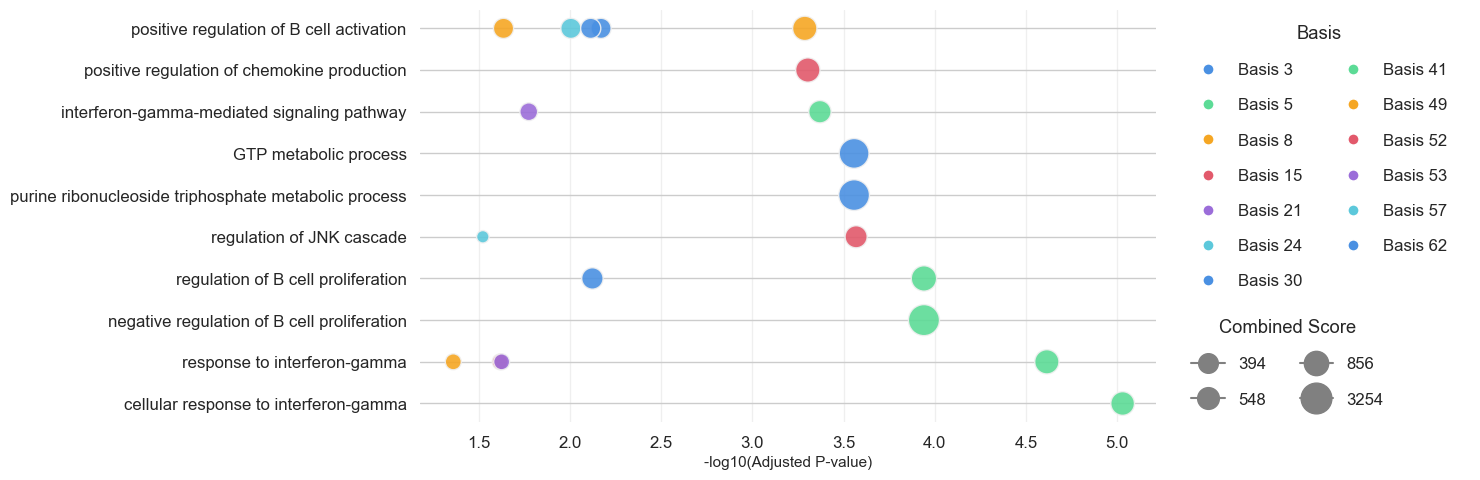

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from textwrap import wrap
from matplotlib.lines import Line2D

# ---------------------- CUSTOM PARAMETERS ----------------------
CSV_PATH = "data/immune_ALL_basis_significant_GO_summary.csv"
SAVE_PATH = "images/linformer_go_immune.png"
TOP_GO_TERMS = 10
#FONT_SANS_SERIF = 'Arial'
PLOT_FIGSIZE = (15, 5)
PALETTE_COLORS = ["#4A90E2", "#5CDB96", "#F5A623", "#E2596B", "#9B6DD9", "#5CC8DB"]
POINT_SIZE_RANGE = (80, 500)
DPI_VALUE = 300
GRID_ALPHA = 0.3
LABEL_SPACING = 1.2
FONT_SCALE = 1.1

#plt.rcParams['font.sans-serif'] = [FONT_SANS_SERIF]
plt.rcParams['axes.unicode_minus'] = False
sns.set(style="whitegrid", font_scale=FONT_SCALE)

df = pd.read_csv(CSV_PATH)
print(df.head())

# Calculate negative log10 P-value
df['neglog10P'] = -np.log10(df['Adjusted_P_value'])
df['GO_short'] = df['GO_term'].str.replace(r" \(GO:\d+\)", "", regex=True).str.strip()

# Group by basis index and GO term
df_basis = df.groupby(['basis_idx', 'GO_short'], as_index=False).agg({
    'neglog10P': 'max',
    'Combined_Score': 'max'
})

# Select top GO terms by maximum significance
top_go_names = (
    df_basis.groupby('GO_short')['neglog10P']
    .max()
    .nlargest(TOP_GO_TERMS)
    .index
)

df_plot = df_basis[df_basis['GO_short'].isin(top_go_names)].copy()

# Log scale for point size
df_plot['size_scaled'] = np.log1p(df_plot['Combined_Score'])

# Sort GO terms by significance
go_order = (
    df_plot.groupby('GO_short')['neglog10P']
    .max()
    .sort_values(ascending=True)
    .index
)

df_plot['GO_short'] = pd.Categorical(
    df_plot['GO_short'],
    categories=go_order,
    ordered=True
)

fig = plt.figure(figsize=PLOT_FIGSIZE)
gs = GridSpec(1, 2, width_ratios=[5, 2])

ax = fig.add_subplot(gs[0])
ax_leg = fig.add_subplot(gs[1])
ax_leg.axis('off')

sns.scatterplot(
    data=df_plot,
    x="neglog10P",
    y="GO_short",
    hue="basis_idx",
    size="size_scaled",
    sizes=POINT_SIZE_RANGE,
    palette=PALETTE_COLORS,
    edgecolor="#f0f0f0",
    linewidth=1,
    alpha=0.9,
    legend=False,
    ax=ax
)

unique_basis = sorted(df_plot['basis_idx'].unique())
hue_handles = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Basis {b}',
           markerfacecolor=PALETTE_COLORS[i % len(PALETTE_COLORS)],
           markersize=8)
    for i, b in enumerate(unique_basis)
]

# Calculate size quantiles
quantiles = df_plot['Combined_Score'].quantile([0.25, 0.5, 0.75, 0.95]).values
size_values = np.unique(np.round(quantiles, 0))

# Size mapping function
def map_size(v, vmin, vmax, smin=POINT_SIZE_RANGE[0], smax=POINT_SIZE_RANGE[1]):
    v_log = np.log1p(v)
    vmin_log = np.log1p(vmin)
    vmax_log = np.log1p(vmax)
    return smin + (v_log - vmin_log) / (vmax_log - vmin_log) * (smax - smin)

vmin = df_plot['Combined_Score'].min()
vmax = df_plot['Combined_Score'].max()

size_handles = [
    Line2D([0], [0], marker='o', color='gray',
           label=f"{int(v)}",
           markerfacecolor='gray',
           markersize=np.sqrt(map_size(v, vmin, vmax)))
    for v in size_values
]

# Add legends to dedicated axis
leg1 = ax_leg.legend(
    hue_handles, [h.get_label() for h in hue_handles],
    title="Basis", loc="upper left", frameon=False, labelspacing=LABEL_SPACING, ncol=2
)

leg2 = ax_leg.legend(
    size_handles, [h.get_label() for h in size_handles],
    title="Combined Score", loc="lower left", frameon=False, labelspacing=LABEL_SPACING, ncol=2
)

ax_leg.add_artist(leg1)

ax.set_xlabel("-log10(Adjusted P-value)", fontsize=11)
ax.set_ylabel("")
ax.grid(axis='x', alpha=GRID_ALPHA)
sns.despine(left=True, bottom=True, ax=ax)

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=DPI_VALUE, bbox_inches='tight', facecolor="white")
plt.show()